## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Load Raw Dataset


In [3]:
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')

print("Dataset loaded!")

print(f"Shape: {df.shape}")

print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Dataset loaded!
Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Check Data Quality


In [4]:
print("MISSING VALUES")
print(df.isnull().sum())

MISSING VALUES
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
print("DUPLICATE ROWS")
print(f"Total Duplicates: {df.duplicated().sum()}")

DUPLICATE ROWS
Total Duplicates: 0


In [6]:
print("DATA TYPES")
print(df.dtypes)

DATA TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


##  Clean Data

In [7]:

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Remove unnecessary column
df.drop(columns=['Row ID'], inplace=True, errors='ignore')

print("Date columns fixed")
print(f"Clean Shape: {df.shape}")

Date columns fixed
Clean Shape: (9994, 20)


## Feature Engineering

In [8]:
# Date features
df['Order Year']        = df['Order Date'].dt.year
df['Order Month']       = df['Order Date'].dt.month
df['Order Month Name']  = df['Order Date'].dt.strftime('%B')
df['Order Quarter']     = df['Order Date'].dt.quarter
df['Order Day']         = df['Order Date'].dt.day_name()

# Business features
df['Days to Ship']      = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %']   = round((df['Profit'] / df['Sales']) * 100, 2)
df['Revenue per Unit']  = round(df['Sales'] / df['Quantity'], 2)

# Profit flag
df['Is Profitable']     = df['Profit'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Shipping speed category
df['Ship Speed'] = df['Days to Ship'].apply(
    lambda x: 'Fast (0-2 days)' if x <= 2 
    else ('Medium (3-5 days)' if x <= 5 
    else 'Slow (6+ days)'))

print("Feature Engineering Done!")
print(f"\nNew Columns Added:")
new_cols = ['Order Year','Order Month','Order Month Name',
            'Order Quarter','Order Day','Days to Ship',
            'Profit Margin %','Revenue per Unit',
            'Is Profitable','Ship Speed']
for col in new_cols:
    print(f"  → {col}")

Feature Engineering Done!

New Columns Added:
  → Order Year
  → Order Month
  → Order Month Name
  → Order Quarter
  → Order Day
  → Days to Ship
  → Profit Margin %
  → Revenue per Unit
  → Is Profitable
  → Ship Speed


## Summary Statistics


In [9]:
print("=" * 50)
print("BUSINESS SUMMARY")
print("=" * 50)

print(f"\n💰 Total Revenue    : ${df['Sales'].sum():,.2f}")
print(f"📈 Total Profit     : ${df['Profit'].sum():,.2f}")
print(f"📦 Total Orders     : {df['Order ID'].nunique():,}")
print(f"👥 Total Customers  : {df['Customer ID'].nunique():,}")
print(f"🛍️  Total Products   : {df['Product ID'].nunique():,}")
print(f"📊 Avg Profit Margin: {df['Profit Margin %'].mean():.2f}%")
print(f"🚚 Avg Days to Ship : {df['Days to Ship'].mean():.1f} days")
print(f"❌ Loss Transactions : {(df['Is Profitable']=='No').sum()}")

BUSINESS SUMMARY

💰 Total Revenue    : $2,297,200.86
📈 Total Profit     : $286,397.02
📦 Total Orders     : 5,009
👥 Total Customers  : 793
🛍️  Total Products   : 1,862
📊 Avg Profit Margin: 12.03%
🚚 Avg Days to Ship : 4.0 days
❌ Loss Transactions : 1936


## Quick Visual Overview

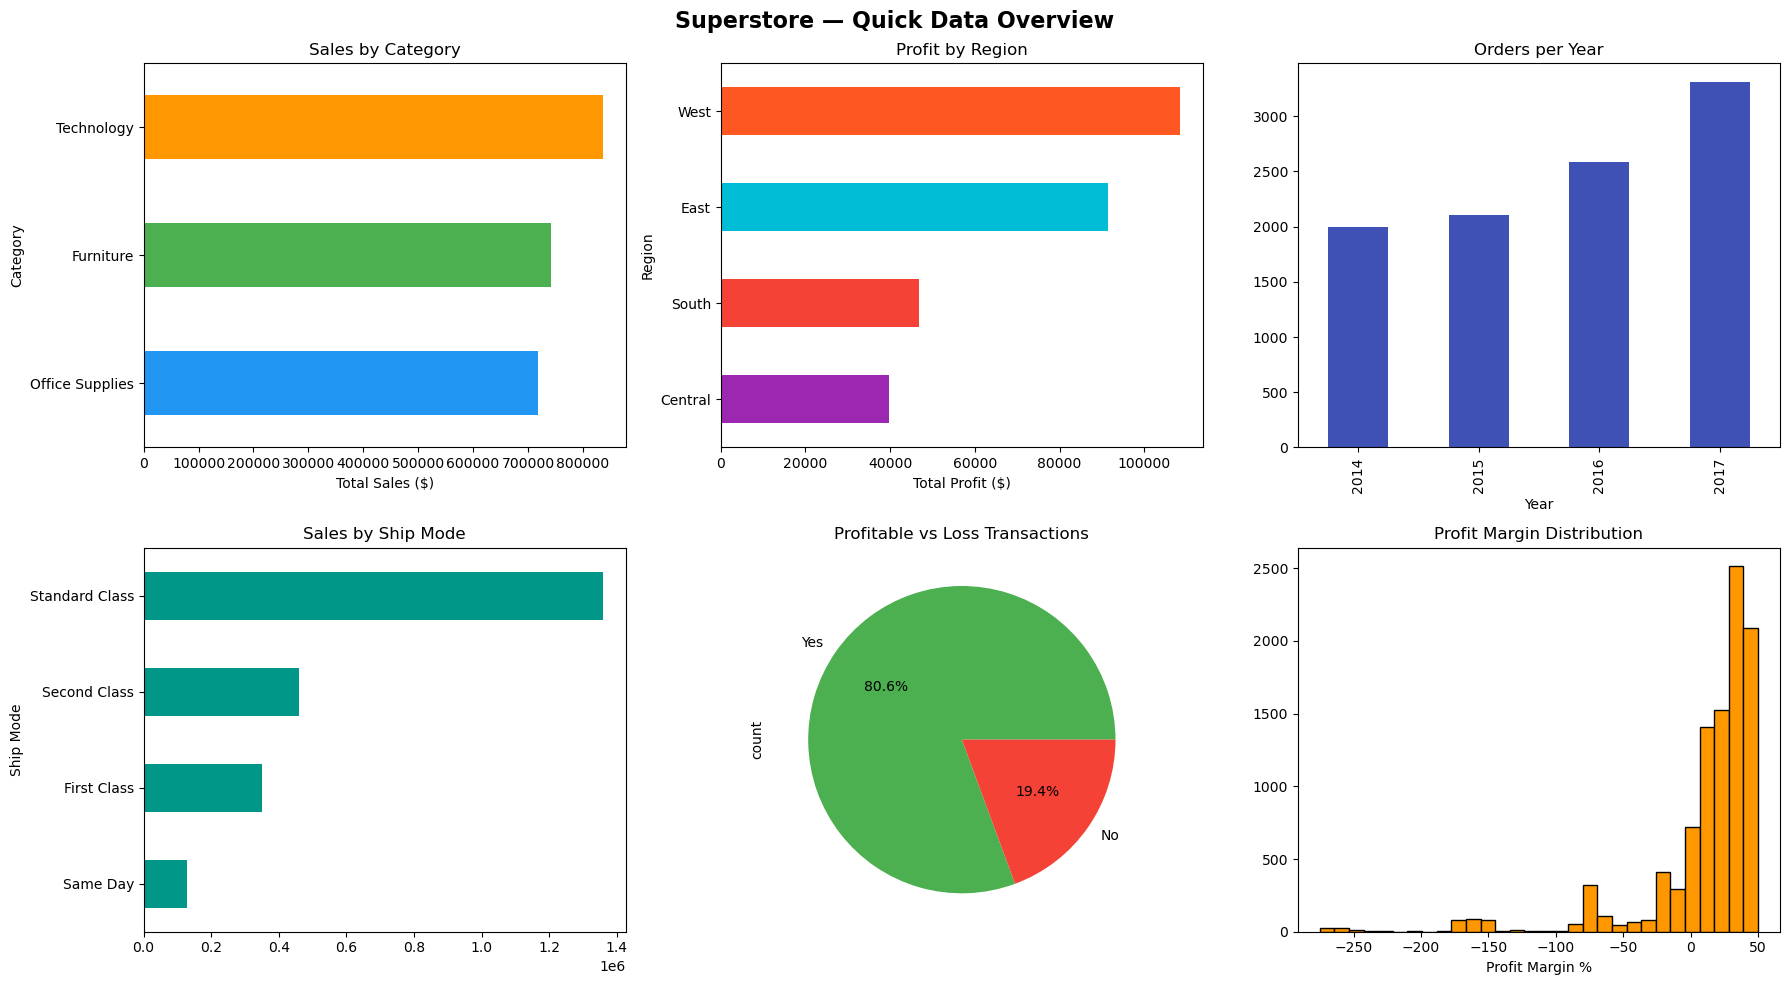

 Chart saved to outputs folder!


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Superstore — Quick Data Overview', fontsize=16, fontweight='bold')

# 1. Sales by Category
df.groupby('Category')['Sales'].sum().sort_values().plot(
    kind='barh', ax=axes[0,0], color=['#2196F3','#4CAF50','#FF9800'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Total Sales ($)')

# 2. Profit by Region
df.groupby('Region')['Profit'].sum().sort_values().plot(
    kind='barh', ax=axes[0,1], color=['#9C27B0','#F44336','#00BCD4','#FF5722'])
axes[0,1].set_title('Profit by Region')
axes[0,1].set_xlabel('Total Profit ($)')

# 3. Orders by Year
df.groupby('Order Year')['Order ID'].count().plot(
    kind='bar', ax=axes[0,2], color='#3F51B5')
axes[0,2].set_title('Orders per Year')
axes[0,2].set_xlabel('Year')

# 4. Sales by Ship Mode
df.groupby('Ship Mode')['Sales'].sum().sort_values().plot(
    kind='barh', ax=axes[1,0], color='#009688')
axes[1,0].set_title('Sales by Ship Mode')

# 5. Profitable vs Loss Transactions
df['Is Profitable'].value_counts().plot(
    kind='pie', ax=axes[1,1], autopct='%1.1f%%',
    colors=['#4CAF50','#F44336'])
axes[1,1].set_title('Profitable vs Loss Transactions')

# 6. Profit Margin Distribution
axes[1,2].hist(df['Profit Margin %'], bins=30, color='#FF9800', edgecolor='black')
axes[1,2].set_title('Profit Margin Distribution')
axes[1,2].set_xlabel('Profit Margin %')

plt.tight_layout()
plt.savefig('../outputs/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved to outputs folder!")

## Save Cleaned CSV

In [11]:
df.to_csv('../data/superstore_cleaned.csv', index=False)
print("Cleaned dataset saved!")
print(f"Shape: {df.shape}")
print(f"Total Columns: {len(df.columns)}")
print("\nAll Columns:")
for col in df.columns:
    print(f"  → {col}")

Cleaned dataset saved!
Shape: (9994, 30)
Total Columns: 30

All Columns:
  → Order ID
  → Order Date
  → Ship Date
  → Ship Mode
  → Customer ID
  → Customer Name
  → Segment
  → Country
  → City
  → State
  → Postal Code
  → Region
  → Product ID
  → Category
  → Sub-Category
  → Product Name
  → Sales
  → Quantity
  → Discount
  → Profit
  → Order Year
  → Order Month
  → Order Month Name
  → Order Quarter
  → Order Day
  → Days to Ship
  → Profit Margin %
  → Revenue per Unit
  → Is Profitable
  → Ship Speed
